<>:112: SyntaxWarning: invalid escape sequence '\G'
<>:112: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_260/3276109247.py:112: SyntaxWarning: invalid escape sequence '\G'
  "\nwith respect to the orientation of $\Gamma$.",


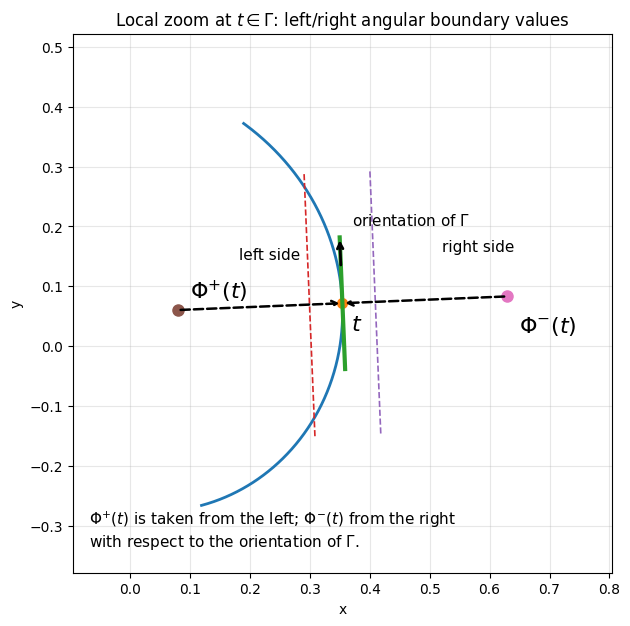

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# -----------------------------
# Local zoom on one logarithmic spiral branch
# illustrating angular boundary values Φ⁺(t), Φ⁻(t)
# -----------------------------

# A single logarithmic spiral branch: z(θ) = a e^{bθ} e^{iθ}
a = 0.35
b = 0.16

# Parameter window for the local branch
theta = np.linspace(-1.15, 1.1, 800)
r = a * np.exp(b * theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

# Marked point t on the branch
theta0 = 0.20
r0 = a * np.exp(b * theta0)
t_point = np.array([r0 * np.cos(theta0), r0 * np.sin(theta0)])

# Tangent vector z'(θ) for the logarithmic spiral
# z'(θ) = a e^{bθ} e^{iθ} (b + i)
tangent = np.array([
    r0 * (b * np.cos(theta0) - np.sin(theta0)),
    r0 * (b * np.sin(theta0) + np.cos(theta0))
])
tangent = tangent / np.linalg.norm(tangent)

# Left and right normals with respect to the orientation
left_normal = np.array([-tangent[1], tangent[0]])
right_normal = -left_normal

# Short oriented segment indicating the local direction of Γ
seg_s = np.linspace(-0.11, 0.11, 40)
seg = t_point[None, :] + seg_s[:, None] * tangent[None, :]

# Create a small "tube" around the curve to visualize the two sides locally
tube_s = np.linspace(-0.22, 0.22, 60)
tube = t_point[None, :] + tube_s[:, None] * tangent[None, :]
tube_left = tube + 0.055 * left_normal[None, :]
tube_right = tube + 0.055 * right_normal[None, :]

# Animation setup
nframes = 72

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')

# Fix limits to show only the local zoom
pad = 0.45
ax.set_xlim(t_point[0] - pad, t_point[0] + pad)
ax.set_ylim(t_point[1] - pad, t_point[1] + pad)

ax.set_title(r"Local zoom at $t\in\Gamma$: left/right angular boundary values")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)

# Static objects
branch_line, = ax.plot(x, y, lw=2, label=r"Local branch of $\Gamma$")
point_t, = ax.plot([t_point[0]], [t_point[1]], marker='o', ms=7)
oriented_seg, = ax.plot(seg[:, 0], seg[:, 1], lw=3)

# Arrow showing orientation
ax.annotate(
    "",
    xy=(seg[-1, 0], seg[-1, 1]),
    xytext=(seg[-10, 0], seg[-10, 1]),
    arrowprops=dict(arrowstyle="->", lw=2)
)

# Labels for the curve and the marked point
ax.text(t_point[0] + 0.015, t_point[1] - 0.045, r"$t$", fontsize=16)
ax.text(seg[-1, 0] + 0.02, seg[-1, 1] + 0.02, r"orientation of $\Gamma$", fontsize=11)

# Small offset curves to suggest "left" and "right" sides
left_side_line, = ax.plot(tube_left[:, 0], tube_left[:, 1], ls='--', lw=1.2)
right_side_line, = ax.plot(tube_right[:, 0], tube_right[:, 1], ls='--', lw=1.2)

ax.text(
    t_point[0] + 0.17 * left_normal[0] + 0.08 * tangent[0],
    t_point[1] + 0.17 * left_normal[1] + 0.08 * tangent[1],
    "left side",
    fontsize=11
)
ax.text(
    t_point[0] + 0.17 * right_normal[0] + 0.08 * tangent[0],
    t_point[1] + 0.17 * right_normal[1] + 0.08 * tangent[1],
    "right side",
    fontsize=11
)

# Animated markers/labels for Φ⁺(t) and Φ⁻(t)
plus_marker, = ax.plot([], [], marker='o', ms=8)
minus_marker, = ax.plot([], [], marker='o', ms=8)

plus_text = ax.text(0, 0, r"$\Phi^{+}(t)$", fontsize=16)
minus_text = ax.text(0, 0, r"$\Phi^{-}(t)$", fontsize=16)

# Dashed approach arrows (updated each frame)
plus_arrow = None
minus_arrow = None

# Explanatory subtitle inside the plot
ax.text(
    0.03, 0.04,
    r"$\Phi^{+}(t)$ is taken from the left; $\Phi^{-}(t)$ from the right"
    "\nwith respect to the orientation of $\Gamma$.",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='bottom'
)

def update(frame):
    global plus_arrow, minus_arrow

    # Remove old arrows
    if plus_arrow is not None:
        plus_arrow.remove()
    if minus_arrow is not None:
        minus_arrow.remove()

    # Move markers from farther away toward the point t
    # progress = 1 means far away, 0 means close to t
    progress = 1.0 - frame / (nframes - 1)
    d = 0.22 * progress + 0.055

    plus_pos = t_point + d * left_normal
    minus_pos = t_point + d * right_normal

    plus_marker.set_data([plus_pos[0]], [plus_pos[1]])
    minus_marker.set_data([minus_pos[0]], [minus_pos[1]])

    plus_text.set_position((plus_pos[0] + 0.02, plus_pos[1] + 0.02))
    minus_text.set_position((minus_pos[0] + 0.02, minus_pos[1] - 0.06))

    plus_arrow = ax.annotate(
        "",
        xy=(t_point[0], t_point[1]),
        xytext=(plus_pos[0], plus_pos[1]),
        arrowprops=dict(arrowstyle="->", lw=1.8, ls="--")
    )
    minus_arrow = ax.annotate(
        "",
        xy=(t_point[0], t_point[1]),
        xytext=(minus_pos[0], minus_pos[1]),
        arrowprops=dict(arrowstyle="->", lw=1.8, ls="--")
    )

    return plus_marker, minus_marker, plus_text, minus_text

anim = FuncAnimation(fig, update, frames=nframes, interval=80, blit=False)

gif_path = "haseman_fig2_local_zoom.gif"
anim.save(gif_path, writer=PillowWriter(fps=12))



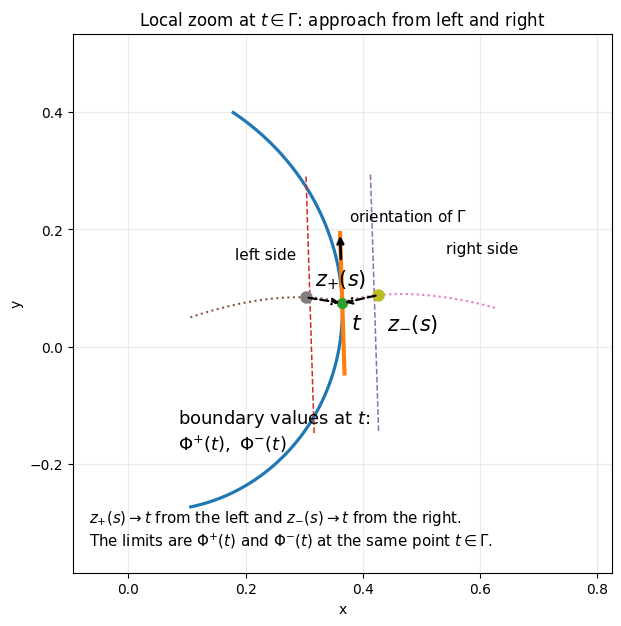

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

a = 0.36
b = 0.17
theta = np.linspace(-1.2, 1.15, 900)
r = a * np.exp(b * theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

theta0 = 0.20
r0 = a * np.exp(b * theta0)
t_point = np.array([r0 * np.cos(theta0), r0 * np.sin(theta0)])

tangent = np.array([
    r0 * (b * np.cos(theta0) - np.sin(theta0)),
    r0 * (b * np.sin(theta0) + np.cos(theta0))
])
tangent = tangent / np.linalg.norm(tangent)

left_normal = np.array([-tangent[1], tangent[0]])
right_normal = -left_normal

seg_s = np.linspace(-0.12, 0.12, 50)
seg = t_point[None, :] + seg_s[:, None] * tangent[None, :]

tube_s = np.linspace(-0.22, 0.22, 70)
tube = t_point[None, :] + tube_s[:, None] * tangent[None, :]
tube_left = tube + 0.055 * left_normal[None, :]
tube_right = tube + 0.055 * right_normal[None, :]

s_path = np.linspace(0, 1, 120)

def curved_approach(side=1):
    normal = left_normal if side == 1 else right_normal
    path = (
        t_point[None, :]
        + (0.26 * (1 - s_path) ** 1.2)[:, None] * normal[None, :]
        + (0.08 * (1 - s_path) * (s_path - 0.2))[:, None] * tangent[None, :]
    )
    return path

path_plus = curved_approach(side=1)
path_minus = curved_approach(side=-1)

nframes = 84

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')

pad = 0.46
ax.set_xlim(t_point[0] - pad, t_point[0] + pad)
ax.set_ylim(t_point[1] - pad, t_point[1] + pad)

ax.set_title(r"Local zoom at $t\in\Gamma$: approach from left and right")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.25)

ax.plot(x, y, lw=2.3)
ax.plot(seg[:, 0], seg[:, 1], lw=3)
ax.plot([t_point[0]], [t_point[1]], marker='o', ms=7)

ax.annotate(
    "",
    xy=(seg[-1, 0], seg[-1, 1]),
    xytext=(seg[-11, 0], seg[-11, 1]),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(t_point[0] + 0.015, t_point[1] - 0.045, r"$t$", fontsize=16)
ax.text(seg[-1, 0] + 0.015, seg[-1, 1] + 0.02, r"orientation of $\Gamma$", fontsize=11)

ax.plot(tube_left[:, 0], tube_left[:, 1], ls="--", lw=1.1)
ax.plot(tube_right[:, 0], tube_right[:, 1], ls="--", lw=1.1)

ax.text(
    t_point[0] + 0.18 * left_normal[0] + 0.08 * tangent[0],
    t_point[1] + 0.18 * left_normal[1] + 0.08 * tangent[1],
    "left side",
    fontsize=11
)
ax.text(
    t_point[0] + 0.18 * right_normal[0] + 0.08 * tangent[0],
    t_point[1] + 0.18 * right_normal[1] + 0.08 * tangent[1],
    "right side",
    fontsize=11
)

ax.plot(path_plus[:, 0], path_plus[:, 1], ls=":", lw=1.5)
ax.plot(path_minus[:, 0], path_minus[:, 1], ls=":", lw=1.5)

plus_marker, = ax.plot([], [], marker='o', ms=8)
minus_marker, = ax.plot([], [], marker='o', ms=8)

plus_text = ax.text(0, 0, r"$z_{+}(s)$", fontsize=15)
minus_text = ax.text(0, 0, r"$z_{-}(s)$", fontsize=15)

boundary_text = ax.text(
    t_point[0] - 0.28,
    t_point[1] - 0.25,
    r"boundary values at $t$:" "\n" r"$\Phi^{+}(t),\ \Phi^{-}(t)$",
    fontsize=13
)

plus_arrow = None
minus_arrow = None

ax.text(
    0.03, 0.04,
    r"$z_{+}(s)\to t$ from the left and $z_{-}(s)\to t$ from the right."
    "\n"
    r"The limits are $\Phi^{+}(t)$ and $\Phi^{-}(t)$ at the same point $t\in\Gamma$.",
    transform=ax.transAxes,
    fontsize=10.8,
    verticalalignment='bottom'
)

def update(frame):
    global plus_arrow, minus_arrow

    if plus_arrow is not None:
        plus_arrow.remove()
    if minus_arrow is not None:
        minus_arrow.remove()

    idx = min(frame, len(path_plus) - 1)
    plus_pos = path_plus[idx]
    minus_pos = path_minus[idx]

    plus_marker.set_data([plus_pos[0]], [plus_pos[1]])
    minus_marker.set_data([minus_pos[0]], [minus_pos[1]])

    plus_text.set_position((plus_pos[0] + 0.015, plus_pos[1] + 0.02))
    minus_text.set_position((minus_pos[0] + 0.015, minus_pos[1] - 0.06))

    plus_arrow = ax.annotate(
        "",
        xy=(t_point[0], t_point[1]),
        xytext=(plus_pos[0], plus_pos[1]),
        arrowprops=dict(arrowstyle="->", lw=1.6, ls="--")
    )
    minus_arrow = ax.annotate(
        "",
        xy=(t_point[0], t_point[1]),
        xytext=(minus_pos[0], minus_pos[1]),
        arrowprops=dict(arrowstyle="->", lw=1.6, ls="--")
    )

    return plus_marker, minus_marker, plus_text, minus_text

anim = FuncAnimation(fig, update, frames=nframes, interval=85, blit=False)
anim.save("haseman_fig2_boundary_limits_corrected.gif", writer=PillowWriter(fps=12))
plt.show()

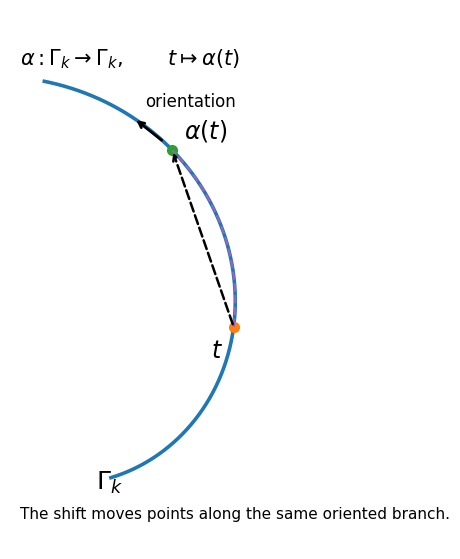

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

a = 0.34
b = 0.18
theta = np.linspace(-1.1, 1.55, 900)
r = a * np.exp(b * theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

theta_t = 0.05
theta_alpha = 0.95

def spiral_point(th):
    rr = a * np.exp(b * th)
    return np.array([rr * np.cos(th), rr * np.sin(th)])

t_point = spiral_point(theta_t)
alpha_point = spiral_point(theta_alpha)

theta_path = np.linspace(theta_t, theta_alpha, 100)
path = np.array([spiral_point(th) for th in theta_path])

theta_orient_1 = 1.00
theta_orient_2 = 1.16
p1 = spiral_point(theta_orient_1)
p2 = spiral_point(theta_orient_2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect("equal")
ax.axis("off")

all_x = np.concatenate([x, [t_point[0], alpha_point[0]]])
all_y = np.concatenate([y, [t_point[1], alpha_point[1]]])
pad_x = 0.18 * (all_x.max() - all_x.min())
pad_y = 0.18 * (all_y.max() - all_y.min())
ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

ax.plot(x, y, lw=2.6)
ax.text(x[30] - 0.05, y[30] - 0.03, r"$\Gamma_k$", fontsize=18)

ax.annotate(
    "",
    xy=(p2[0], p2[1]),
    xytext=(p1[0], p1[1]),
    arrowprops=dict(arrowstyle="->", lw=2),
)
ax.text(p2[0] + 0.02, p2[1] + 0.02, r"orientation", fontsize=12)

ax.plot([t_point[0]], [t_point[1]], marker="o", ms=7)
ax.text(t_point[0] - 0.04, t_point[1] - 0.055, r"$t$", fontsize=17)

alpha_marker, = ax.plot([], [], marker="o", ms=7)
alpha_label = ax.text(0, 0, "", fontsize=17)

moving_point, = ax.plot([], [], marker="o", ms=9)
path_line, = ax.plot([], [], ls="--", lw=1.6)

shift_arrow = None

ax.text(
    0.04,
    0.93,
    r"$\alpha:\Gamma_k\to\Gamma_k,\qquad t\mapsto \alpha(t)$",
    transform=ax.transAxes,
    fontsize=15,
    va="top",
)
#ax.text(
#    0.94,
#    0.86,
#    r"$(V_{\alpha}f)(t)=f(\alpha(t))$",
#    transform=ax.transAxes,
#    fontsize=15,
#    va="top",
#)

ax.text(
    0.04,
    0.05,
    r"The shift moves points along the same oriented branch.",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom",
)

nframes = len(path) + 18

def update(frame):
    global shift_arrow

    if shift_arrow is not None:
        shift_arrow.remove()
        shift_arrow = None

    if frame < len(path):
        current = path[frame]
        moving_point.set_data([current[0]], [current[1]])
        path_line.set_data(path[: frame + 1, 0], path[: frame + 1, 1])
        alpha_marker.set_data([], [])
        alpha_label.set_text("")
    else:
        moving_point.set_data([], [])
        path_line.set_data(path[:, 0], path[:, 1])
        alpha_marker.set_data([alpha_point[0]], [alpha_point[1]])
        alpha_label.set_position((alpha_point[0] + 0.02, alpha_point[1] + 0.02))
        alpha_label.set_text(r"$\alpha(t)$")

        shift_arrow = ax.annotate(
            "",
            xy=(alpha_point[0], alpha_point[1]),
            xytext=(t_point[0], t_point[1]),
            arrowprops=dict(arrowstyle="->", lw=1.8, ls="--"),
        )

    return moving_point, path_line, alpha_marker, alpha_label

anim = FuncAnimation(fig, update, frames=nframes, interval=70, blit=False)
anim.save("haseman_fig3_shift_alpha.gif", writer=PillowWriter(fps=14))
plt.show()

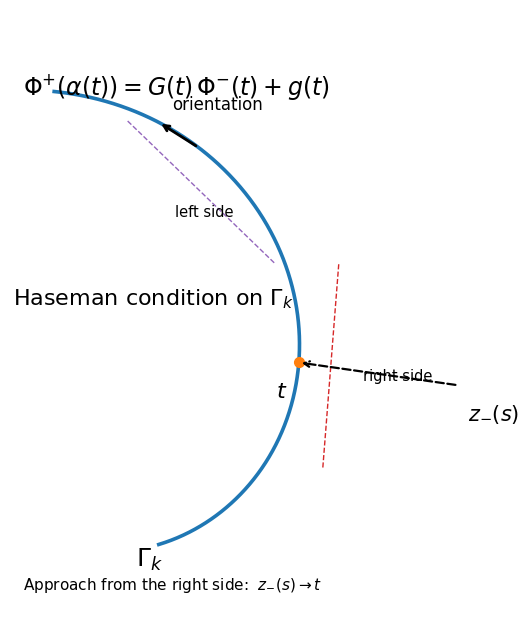

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ------------------------------------------------------------
# Figure 4: visualizing the Haseman boundary condition
#   Φ⁺(α(t)) = G(t) Φ⁻(t) + g(t)
# on one branch Γ_k of the logarithmic star.
# ------------------------------------------------------------

# One logarithmic spiral branch
a = 0.34
b = 0.18
theta = np.linspace(-1.1, 1.65, 1000)
r = a * np.exp(b * theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

def spiral_point(th):
    rr = a * np.exp(b * th)
    return np.array([rr * np.cos(th), rr * np.sin(th)])

def unit_tangent(th):
    rr = a * np.exp(b * th)
    vec = np.array([
        rr * (b * np.cos(th) - np.sin(th)),
        rr * (b * np.sin(th) + np.cos(th))
    ])
    return vec / np.linalg.norm(vec)

# Two points on the same branch
theta_t = 0.10
theta_alpha = 0.98
t_point = spiral_point(theta_t)
alpha_point = spiral_point(theta_alpha)

tan_t = unit_tangent(theta_t)
tan_alpha = unit_tangent(theta_alpha)

left_t = np.array([-tan_t[1], tan_t[0]])
right_t = -left_t

left_alpha = np.array([-tan_alpha[1], tan_alpha[0]])
right_alpha = -left_alpha

# Local oriented segments near t and alpha(t)
seg_s = np.linspace(-0.11, 0.11, 45)
seg_t = t_point[None, :] + seg_s[:, None] * tan_t[None, :]
seg_alpha = alpha_point[None, :] + seg_s[:, None] * tan_alpha[None, :]

# Offset guides to indicate left/right sides locally
tube_s = np.linspace(-0.16, 0.16, 60)
tube_t = t_point[None, :] + tube_s[:, None] * tan_t[None, :]
tube_alpha = alpha_point[None, :] + tube_s[:, None] * tan_alpha[None, :]
tube_t_right = tube_t + 0.05 * right_t[None, :]
tube_alpha_left = tube_alpha + 0.05 * left_alpha[None, :]

# Approach paths
s_path = np.linspace(0, 1, 80)

def curved_path_to_point(point, tangent, normal, side="right"):
    # side="right" means approach using the right normal
    # side="left" means approach using the left normal
    sign_normal = 1.0 if side == "left" else -1.0
    return (
        point[None, :]
        + (0.25 * (1 - s_path) ** 1.15)[:, None] * (sign_normal * normal[None, :])
        + (0.08 * (1 - s_path) * (s_path - 0.2))[:, None] * tangent[None, :]
    )

path_minus = curved_path_to_point(t_point, tan_t, left_t, side="right")
path_plus = curved_path_to_point(alpha_point, tan_alpha, left_alpha, side="left")

# Shift path along the branch from t to alpha(t)
theta_shift = np.linspace(theta_t, theta_alpha, 110)
shift_path = np.array([spiral_point(th) for th in theta_shift])

# Orientation arrow on the branch
p1 = spiral_point(1.10)
p2 = spiral_point(1.27)

# Phase lengths
n1 = len(path_minus)      # approach from the right to t
hold1 = 14                # show Φ⁻(t)
n2 = len(shift_path)      # shift from t to alpha(t)
hold2 = 14                # show α(t)
n3 = len(path_plus)       # approach from the left to alpha(t)
hold3 = 28                # show Φ⁺(α(t)) and the equation
nframes = n1 + hold1 + n2 + hold2 + n3 + hold3

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
ax.axis("off")

all_x = np.concatenate([x, [t_point[0], alpha_point[0]]])
all_y = np.concatenate([y, [t_point[1], alpha_point[1]]])
pad_x = 0.18 * (all_x.max() - all_x.min())
pad_y = 0.18 * (all_y.max() - all_y.min())
ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# Static branch and labels
ax.plot(x, y, lw=2.6)
ax.text(x[20] - 0.05, y[20] - 0.04, r"$\Gamma_k$", fontsize=18)

ax.annotate(
    "",
    xy=(p2[0], p2[1]),
    xytext=(p1[0], p1[1]),
    arrowprops=dict(arrowstyle="->", lw=2),
)
ax.text(p2[0] + 0.02, p2[1] + 0.02, r"orientation", fontsize=12)

# Mark t and alpha(t) base positions
ax.plot([t_point[0]], [t_point[1]], marker="o", ms=7)
ax.text(t_point[0] - 0.035, t_point[1] - 0.055, r"$t$", fontsize=16)

alpha_base_marker, = ax.plot([], [], marker="o", ms=7)
alpha_base_label = ax.text(0, 0, "", fontsize=16)

# Local side guides
ax.plot(tube_t_right[:, 0], tube_t_right[:, 1], ls="--", lw=1.0)
ax.plot(tube_alpha_left[:, 0], tube_alpha_left[:, 1], ls="--", lw=1.0)

ax.text(
    t_point[0] + 0.12 * right_t[0] - 0.02,
    t_point[1] + 0.12 * right_t[1] - 0.02,
    "right side",
    fontsize=10.5
)
ax.text(
    alpha_point[0] + 0.12 * left_alpha[0] + 0.01,
    alpha_point[1] + 0.12 * left_alpha[1] + 0.01,
    "left side",
    fontsize=10.5
)

# Animated objects
approach_minus_marker, = ax.plot([], [], marker="o", ms=8)
approach_plus_marker, = ax.plot([], [], marker="o", ms=8)
moving_shift_marker, = ax.plot([], [], marker="o", ms=9)

path_minus_line, = ax.plot([], [], ls=":", lw=1.4)
path_plus_line, = ax.plot([], [], ls=":", lw=1.4)
shift_line, = ax.plot([], [], ls="--", lw=1.6)

minus_text = ax.text(0, 0, "", fontsize=15)
plus_text = ax.text(0, 0, "", fontsize=15)
minus_boundary_text = ax.text(0, 0, "", fontsize=15)
plus_boundary_text = ax.text(0, 0, "", fontsize=15)

# Static math text
ax.text(
    0.01,
    0.55,
    r"Haseman condition on $\Gamma_k$",
    transform=ax.transAxes,
    fontsize=16,
    va="top",
)
ax.text(
    0.04,
    0.90,
    r"$\Phi^{+}(\alpha(t)) = G(t)\,\Phi^{-}(t) + g(t)$",
    transform=ax.transAxes,
    fontsize=17,
    va="top",
)

bottom_note = ax.text(
    0.04,
    0.05,
    "",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom",
)

minus_arrow = None
shift_arrow = None
plus_arrow = None

def clear_arrow(arrow_obj):
    if arrow_obj is not None:
        arrow_obj.remove()
    return None

def update(frame):
    global minus_arrow, shift_arrow, plus_arrow

    minus_arrow = clear_arrow(minus_arrow)
    shift_arrow = clear_arrow(shift_arrow)
    plus_arrow = clear_arrow(plus_arrow)

    # Reset objects that are only visible in some phases
    approach_minus_marker.set_data([], [])
    approach_plus_marker.set_data([], [])
    moving_shift_marker.set_data([], [])
    alpha_base_marker.set_data([], [])
    alpha_base_label.set_text("")
    path_minus_line.set_data([], [])
    path_plus_line.set_data([], [])
    shift_line.set_data([], [])

    minus_text.set_text("")
    plus_text.set_text("")
    minus_boundary_text.set_text("")
    plus_boundary_text.set_text("")
    bottom_note.set_text("")

    # Phase 1: approach to t from the right -> Φ^-(t)
    if frame < n1:
        idx = frame
        pos = path_minus[idx]
        approach_minus_marker.set_data([pos[0]], [pos[1]])
        path_minus_line.set_data(path_minus[:idx + 1, 0], path_minus[:idx + 1, 1])
        minus_text.set_text(r"$z_{-}(s)$")
        minus_text.set_position((pos[0] + 0.015, pos[1] - 0.055))

        minus_arrow = ax.annotate(
            "",
            xy=(t_point[0], t_point[1]),
            xytext=(pos[0], pos[1]),
            arrowprops=dict(arrowstyle="->", lw=1.6, ls="--"),
        )
        bottom_note.set_text(r"Approach from the right side:  $z_{-}(s)\to t$")

    # Hold after phase 1
    elif frame < n1 + hold1:
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.12, t_point[1] - 0.14))
        bottom_note.set_text(r"Right boundary limit at the point $t$")

    # Phase 2: shift t -> alpha(t)
    elif frame < n1 + hold1 + n2:
        idx = frame - (n1 + hold1)
        pos = shift_path[idx]
        moving_shift_marker.set_data([pos[0]], [pos[1]])
        shift_line.set_data(shift_path[:idx + 1, 0], shift_path[:idx + 1, 1])

        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.12, t_point[1] - 0.14))

        bottom_note.set_text(r"The shift moves $t$ along the same branch to $\alpha(t)$")

    # Hold after phase 2
    elif frame < n1 + hold1 + n2 + hold2:
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.12, t_point[1] - 0.14))

        alpha_base_marker.set_data([alpha_point[0]], [alpha_point[1]])
        alpha_base_label.set_position((alpha_point[0] + 0.02, alpha_point[1] + 0.02))
        alpha_base_label.set_text(r"$\alpha(t)$")

        shift_line.set_data(shift_path[:, 0], shift_path[:, 1])
        shift_arrow = ax.annotate(
            "",
            xy=(alpha_point[0], alpha_point[1]),
            xytext=(t_point[0], t_point[1]),
            arrowprops=dict(arrowstyle="->", lw=1.6, ls="--"),
        )
        bottom_note.set_text(r"Shifted point $\alpha(t)$ on the same oriented branch")

    # Phase 3: approach to alpha(t) from the left -> Φ^+(alpha(t))
    elif frame < n1 + hold1 + n2 + hold2 + n3:
        idx = frame - (n1 + hold1 + n2 + hold2)

        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.12, t_point[1] - 0.14))

        alpha_base_marker.set_data([alpha_point[0]], [alpha_point[1]])
        alpha_base_label.set_position((alpha_point[0] + 0.02, alpha_point[1] + 0.02))
        alpha_base_label.set_text(r"$\alpha(t)$")

        pos = path_plus[idx]
        approach_plus_marker.set_data([pos[0]], [pos[1]])
        path_plus_line.set_data(path_plus[:idx + 1, 0], path_plus[:idx + 1, 1])
        plus_text.set_text(r"$z_{+}(s)$")
        plus_text.set_position((pos[0] + 0.015, pos[1] + 0.02))

        plus_arrow = ax.annotate(
            "",
            xy=(alpha_point[0], alpha_point[1]),
            xytext=(pos[0], pos[1]),
            arrowprops=dict(arrowstyle="->", lw=1.6, ls="--"),
        )
        bottom_note.set_text(r"Approach from the left side:  $z_{+}(s)\to \alpha(t)$")

    # Final hold
    else:
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.12, t_point[1] - 0.14))

        alpha_base_marker.set_data([alpha_point[0]], [alpha_point[1]])
        alpha_base_label.set_position((alpha_point[0] + 0.02, alpha_point[1] + 0.02))
        alpha_base_label.set_text(r"$\alpha(t)$")

        plus_boundary_text.set_text(r"$\Phi^{+}(\alpha(t))$")
        plus_boundary_text.set_position((alpha_point[0] - 0.02, alpha_point[1] + 0.10))

        shift_line.set_data(shift_path[:, 0], shift_path[:, 1])

        bottom_note.set_text(
            r"The Haseman condition couples the right trace at $t$"
            "\n"
            r"with the left trace at the shifted point $\alpha(t)$."
        )

    return (
        approach_minus_marker, approach_plus_marker, moving_shift_marker,
        path_minus_line, path_plus_line, shift_line,
        minus_text, plus_text, minus_boundary_text, plus_boundary_text,
        alpha_base_marker, alpha_base_label, bottom_note
    )

anim = FuncAnimation(fig, update, frames=nframes, interval=75, blit=False)

gif_path = "haseman_fig4_condition.gif"
anim.save(gif_path, writer=PillowWriter(fps=13))


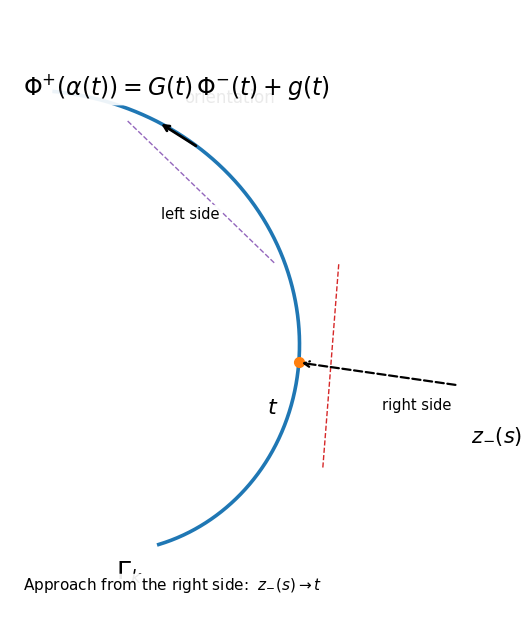

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ------------------------------------------------------------
# Figure 4 (revised): avoid overlapping labels
#   Φ⁺(α(t)) = G(t) Φ⁻(t) + g(t)
# ------------------------------------------------------------

a = 0.34
b = 0.18
theta = np.linspace(-1.1, 1.65, 1000)
r = a * np.exp(b * theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

def spiral_point(th):
    rr = a * np.exp(b * th)
    return np.array([rr * np.cos(th), rr * np.sin(th)])

def unit_tangent(th):
    rr = a * np.exp(b * th)
    vec = np.array([
        rr * (b * np.cos(th) - np.sin(th)),
        rr * (b * np.sin(th) + np.cos(th))
    ])
    return vec / np.linalg.norm(vec)

theta_t = 0.10
theta_alpha = 0.98
t_point = spiral_point(theta_t)
alpha_point = spiral_point(theta_alpha)

tan_t = unit_tangent(theta_t)
tan_alpha = unit_tangent(theta_alpha)

left_t = np.array([-tan_t[1], tan_t[0]])
right_t = -left_t

left_alpha = np.array([-tan_alpha[1], tan_alpha[0]])
right_alpha = -left_alpha

tube_s = np.linspace(-0.16, 0.16, 60)
tube_t = t_point[None, :] + tube_s[:, None] * tan_t[None, :]
tube_alpha = alpha_point[None, :] + tube_s[:, None] * tan_alpha[None, :]
tube_t_right = tube_t + 0.05 * right_t[None, :]
tube_alpha_left = tube_alpha + 0.05 * left_alpha[None, :]

s_path = np.linspace(0, 1, 80)

def curved_path_to_point(point, tangent, normal, side="right"):
    sign_normal = 1.0 if side == "left" else -1.0
    return (
        point[None, :]
        + (0.25 * (1 - s_path) ** 1.15)[:, None] * (sign_normal * normal[None, :])
        + (0.08 * (1 - s_path) * (s_path - 0.2))[:, None] * tangent[None, :]
    )

path_minus = curved_path_to_point(t_point, tan_t, left_t, side="right")
path_plus = curved_path_to_point(alpha_point, tan_alpha, left_alpha, side="left")

theta_shift = np.linspace(theta_t, theta_alpha, 110)
shift_path = np.array([spiral_point(th) for th in theta_shift])

p1 = spiral_point(1.10)
p2 = spiral_point(1.27)

n1 = len(path_minus)
hold1 = 14
n2 = len(shift_path)
hold2 = 14
n3 = len(path_plus)
hold3 = 28
nframes = n1 + hold1 + n2 + hold2 + n3 + hold3

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
ax.axis("off")

all_x = np.concatenate([x, [t_point[0], alpha_point[0]]])
all_y = np.concatenate([y, [t_point[1], alpha_point[1]]])
pad_x = 0.18 * (all_x.max() - all_x.min())
pad_y = 0.18 * (all_y.max() - all_y.min())
ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# Light text background to keep labels readable
label_box = dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.92)

# Static branch and labels
ax.plot(x, y, lw=2.6)
ax.text(x[18] - 0.08, y[18] - 0.06, r"$\Gamma_k$", fontsize=18, bbox=label_box)

ax.annotate(
    "",
    xy=(p2[0], p2[1]),
    xytext=(p1[0], p1[1]),
    arrowprops=dict(arrowstyle="->", lw=2),
)
ax.text(p2[0] + 0.04, p2[1] + 0.03, r"orientation", fontsize=12, bbox=label_box)

# Base point t
ax.plot([t_point[0]], [t_point[1]], marker="o", ms=7)
ax.text(t_point[0] - 0.05, t_point[1] - 0.08, r"$t$", fontsize=16, bbox=label_box)

# Alpha point base label/marker (animated)
alpha_base_marker, = ax.plot([], [], marker="o", ms=7)
alpha_base_label = ax.text(0, 0, "", fontsize=16, bbox=label_box)

# Local side guides
ax.plot(tube_t_right[:, 0], tube_t_right[:, 1], ls="--", lw=1.0)
ax.plot(tube_alpha_left[:, 0], tube_alpha_left[:, 1], ls="--", lw=1.0)

# Reposition side labels farther away
ax.text(
    t_point[0] + 0.18 * right_t[0] - 0.05,
    t_point[1] + 0.18 * right_t[1] - 0.06,
    "right side",
    fontsize=10.5,
    bbox=label_box
)
ax.text(
    alpha_point[0] + 0.18 * left_alpha[0] + 0.03,
    alpha_point[1] + 0.18 * left_alpha[1] + 0.05,
    "left side",
    fontsize=10.5,
    bbox=label_box
)

# Animated objects
approach_minus_marker, = ax.plot([], [], marker="o", ms=8)
approach_plus_marker, = ax.plot([], [], marker="o", ms=8)
moving_shift_marker, = ax.plot([], [], marker="o", ms=9)

path_minus_line, = ax.plot([], [], ls=":", lw=1.4)
path_plus_line, = ax.plot([], [], ls=":", lw=1.4)
shift_line, = ax.plot([], [], ls="--", lw=1.6)

minus_text = ax.text(0, 0, "", fontsize=15, bbox=label_box)
plus_text = ax.text(0, 0, "", fontsize=15, bbox=label_box)
minus_boundary_text = ax.text(0, 0, "", fontsize=15, bbox=label_box)
plus_boundary_text = ax.text(0, 0, "", fontsize=15, bbox=label_box)

# Main text
#ax.text(
#    0.4,
#    0.95,
#    r"Haseman condition on $\Gamma_k$",
#    transform=ax.transAxes,
#    fontsize=16,
#    va="top",
#    bbox=label_box
#)
ax.text(
    0.04,
    0.90,
    r"$\Phi^{+}(\alpha(t)) = G(t)\,\Phi^{-}(t) + g(t)$",
    transform=ax.transAxes,
    fontsize=17,
    va="top",
    bbox=label_box
)

bottom_note = ax.text(
    0.04,
    0.05,
    "",
    transform=ax.transAxes,
    fontsize=11,
    va="bottom",
    bbox=label_box
)

minus_arrow = None
shift_arrow = None
plus_arrow = None

def clear_arrow(arrow_obj):
    if arrow_obj is not None:
        arrow_obj.remove()
    return None

def update(frame):
    global minus_arrow, shift_arrow, plus_arrow

    minus_arrow = clear_arrow(minus_arrow)
    shift_arrow = clear_arrow(shift_arrow)
    plus_arrow = clear_arrow(plus_arrow)

    approach_minus_marker.set_data([], [])
    approach_plus_marker.set_data([], [])
    moving_shift_marker.set_data([], [])
    alpha_base_marker.set_data([], [])
    alpha_base_label.set_text("")
    path_minus_line.set_data([], [])
    path_plus_line.set_data([], [])
    shift_line.set_data([], [])

    minus_text.set_text("")
    plus_text.set_text("")
    minus_boundary_text.set_text("")
    plus_boundary_text.set_text("")
    bottom_note.set_text("")

    # Phase 1: approach to t from the right
    if frame < n1:
        idx = frame
        pos = path_minus[idx]
        approach_minus_marker.set_data([pos[0]], [pos[1]])
        path_minus_line.set_data(path_minus[:idx + 1, 0], path_minus[:idx + 1, 1])

        minus_text.set_text(r"$z_{-}(s)$")
        minus_text.set_position((pos[0] + 0.02, pos[1] - 0.09))

        minus_arrow = ax.annotate(
            "",
            xy=(t_point[0], t_point[1]),
            xytext=(pos[0], pos[1]),
            arrowprops=dict(arrowstyle="->", lw=1.6, ls="--"),
        )
        bottom_note.set_text(r"Approach from the right side:  $z_{-}(s)\to t$")

    # Hold after phase 1
    elif frame < n1 + hold1:
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.22, t_point[1] - 0.20))
        bottom_note.set_text(r"Right boundary limit at the point $t$")

    # Phase 2: shift from t to alpha(t)
    elif frame < n1 + hold1 + n2:
        idx = frame - (n1 + hold1)
        pos = shift_path[idx]
        moving_shift_marker.set_data([pos[0]], [pos[1]])
        shift_line.set_data(shift_path[:idx + 1, 0], shift_path[:idx + 1, 1])

        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.22, t_point[1] - 0.20))
        bottom_note.set_text(r"The shift moves $t$ along the same branch to $\alpha(t)$")

    # Hold after phase 2
    elif frame < n1 + hold1 + n2 + hold2:
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.22, t_point[1] - 0.20))

        alpha_base_marker.set_data([alpha_point[0]], [alpha_point[1]])
        alpha_base_label.set_position((alpha_point[0] + 0.10, alpha_point[1] - 0.02))
        alpha_base_label.set_text(r"$\alpha(t)$")

        shift_line.set_data(shift_path[:, 0], shift_path[:, 1])
        shift_arrow = ax.annotate(
            "",
            xy=(alpha_point[0], alpha_point[1]),
            xytext=(t_point[0], t_point[1]),
            arrowprops=dict(arrowstyle="->", lw=1.6, ls="--"),
        )
        bottom_note.set_text(r"Shifted point $\alpha(t)$ on the same oriented branch")

    # Phase 3: approach to alpha(t) from the left
    elif frame < n1 + hold1 + n2 + hold2 + n3:
        idx = frame - (n1 + hold1 + n2 + hold2)

        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.22, t_point[1] - 0.20))

        alpha_base_marker.set_data([alpha_point[0]], [alpha_point[1]])
        alpha_base_label.set_position((alpha_point[0] + 0.10, alpha_point[1] - 0.02))
        alpha_base_label.set_text(r"$\alpha(t)$")

        pos = path_plus[idx]
        approach_plus_marker.set_data([pos[0]], [pos[1]])
        path_plus_line.set_data(path_plus[:idx + 1, 0], path_plus[:idx + 1, 1])

        plus_text.set_text(r"$z_{+}(s)$")
        plus_text.set_position((pos[0] + 0.03, pos[1] + 0.05))

        plus_arrow = ax.annotate(
            "",
            xy=(alpha_point[0], alpha_point[1]),
            xytext=(pos[0], pos[1]),
            arrowprops=dict(arrowstyle="->", lw=1.6, ls="--"),
        )
        bottom_note.set_text(r"Approach from the left side:  $z_{+}(s)\to \alpha(t)$")

    # Final hold
    else:
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.22, t_point[1] - 0.20))

        alpha_base_marker.set_data([alpha_point[0]], [alpha_point[1]])
        alpha_base_label.set_position((alpha_point[0] + 0.10, alpha_point[1] - 0.02))
        alpha_base_label.set_text(r"$\alpha(t)$")

        plus_boundary_text.set_text(r"$\Phi^{+}(\alpha(t))$")
        plus_boundary_text.set_position((alpha_point[0] - 0.26, alpha_point[1] + 0.18))

        shift_line.set_data(shift_path[:, 0], shift_path[:, 1])

        bottom_note.set_text(
            r"The Haseman condition couples the right trace at $t$"
            "\n"
            r"with the left trace at the shifted point $\alpha(t)$."
        )

    return (
        approach_minus_marker, approach_plus_marker, moving_shift_marker,
        path_minus_line, path_plus_line, shift_line,
        minus_text, plus_text, minus_boundary_text, plus_boundary_text,
        alpha_base_marker, alpha_base_label, bottom_note
    )

anim = FuncAnimation(fig, update, frames=nframes, interval=75, blit=False)

gif_path = "haseman_fig4_condition_no_overlap.gif"
anim.save(gif_path, writer=PillowWriter(fps=13))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ------------------------------------------------------------
# Figure 5 (simplified): Cauchy-type integral representation
#   Φ(z) = (1/2πi) ∫_Γ φ(τ)/(τ-z) dτ
# A clearer visual:
#   1) one sample boundary point τ contributes to Φ(z)
#   2) then several sample points illustrate "integrate over Γ"
# ------------------------------------------------------------

# ---------- Geometry: logarithmic star ----------
a = 0.28
b = 0.12
n_branches = 4
theta = np.linspace(-1.2, 1.4, 260)

def spiral_branch(angle_shift):
    r = a * np.exp(b * theta)
    x = r * np.cos(theta + angle_shift)
    y = r * np.sin(theta + angle_shift)
    return x, y

branches = [spiral_branch(2 * np.pi * k / n_branches) for k in range(n_branches)]

def point_on_branch(th, angle_shift):
    rr = a * np.exp(b * th)
    return np.array([rr * np.cos(th + angle_shift), rr * np.sin(th + angle_shift)])

# Three sample boundary points on Γ
tau1 = point_on_branch(0.15, 0.0)
tau2 = point_on_branch(0.55, np.pi / 2)
tau3 = point_on_branch(-0.20, np.pi)

tau_points = [tau1, tau2, tau3]

# Evaluation point outside Γ
z_point = np.array([1.02, 0.48])

# Path for the first animated sample point τ moving along one branch
theta_tau_path = np.linspace(-0.75, 0.35, 36)
tau_path = np.array([point_on_branch(th, 0.0) for th in theta_tau_path])

# Animation timing
n1 = len(tau_path)   # move one tau along Γ
hold1 = 10           # hold single contribution
n2 = 18              # show multiple contributions
hold2 = 24           # final hold
nframes = n1 + hold1 + n2 + hold2

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.set_aspect("equal")
ax.axis("off")

# Limits
all_x = np.concatenate([np.concatenate([br[0] for br in branches]), [z_point[0]]])
all_y = np.concatenate([np.concatenate([br[1] for br in branches]), [z_point[1]]])
pad_x = 0.22 * (all_x.max() - all_x.min())
pad_y = 0.22 * (all_y.max() - all_y.min())
ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

label_box = dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.95)

# Draw Γ
for x, y in branches:
    ax.plot(x, y, lw=2.2)

# Orientation arrow on one branch
x0, y0 = branches[0]
ax.annotate(
    "",
    xy=(x0[-1], y0[-1]),
    xytext=(x0[-18], y0[-18]),
    arrowprops=dict(arrowstyle="->", lw=1.7),
)

# Static labels
ax.text(-0.20, 0.18, r"$\Gamma$", fontsize=18, bbox=label_box)
ax.text(-0.72, -0.78, r"boundary density $\varphi$ on $\Gamma$", fontsize=12, bbox=label_box)

# z and Φ(z)
ax.plot([z_point[0]], [z_point[1]], marker="o", ms=7)
ax.text(z_point[0] + 0.05, z_point[1] - 0.02, r"$z$", fontsize=16, bbox=label_box)
ax.text(z_point[0] + 0.03, z_point[1] + 0.16, r"$\Phi(z)$", fontsize=17, bbox=label_box)

# Formula
ax.text(
    0.04, 0.95,
    r"$\Phi(z)=\dfrac{1}{2\pi i}\int_{\Gamma}\dfrac{\varphi(\tau)}{\tau-z}\,d\tau$",
    transform=ax.transAxes,
    fontsize=16,
    va="top",
    bbox=label_box
)

# Bottom explanation
bottom_note = ax.text(
    0.04, 0.05, "",
    transform=ax.transAxes,
    fontsize=10.8,
    va="bottom",
    bbox=label_box
)

# Animated artists
tau_marker, = ax.plot([], [], marker="o", ms=7)
tau_label = ax.text(0, 0, "", fontsize=15, bbox=label_box)
single_contrib_line, = ax.plot([], [], ls="--", lw=1.4)

# Three sample contributions for the second stage
sample_markers = [ax.plot([], [], marker="o", ms=6.5)[0] for _ in range(3)]
sample_labels = [ax.text(0, 0, "", fontsize=13, bbox=label_box) for _ in range(3)]
sample_lines = [ax.plot([], [], ls="--", lw=1.2)[0] for _ in range(3)]

# A simple explanatory label for the second stage
all_tau_text = ax.text(0, 0, "", fontsize=12, bbox=label_box)

def update(frame):
    # Reset dynamic artists
    tau_marker.set_data([], [])
    tau_label.set_text("")
    single_contrib_line.set_data([], [])
    all_tau_text.set_text("")

    for m in sample_markers:
        m.set_data([], [])
    for lab in sample_labels:
        lab.set_text("")
    for ln in sample_lines:
        ln.set_data([], [])

    # Stage 1: one sample boundary point τ
    if frame < n1:
        idx = frame
        tau = tau_path[idx]
        tau_marker.set_data([tau[0]], [tau[1]])
        tau_label.set_text(r"$\tau$")
        tau_label.set_position((tau[0] + 0.04, tau[1] + 0.03))
        single_contrib_line.set_data([tau[0], z_point[0]], [tau[1], z_point[1]])
        bottom_note.set_text(r"One sample boundary point $\tau\in\Gamma$ contributes to $\Phi(z)$.")

    # Hold stage 1
    elif frame < n1 + hold1:
        tau = tau_path[-1]
        tau_marker.set_data([tau[0]], [tau[1]])
        tau_label.set_text(r"$\tau$")
        tau_label.set_position((tau[0] + 0.04, tau[1] + 0.03))
        single_contrib_line.set_data([tau[0], z_point[0]], [tau[1], z_point[1]])
        bottom_note.set_text(r"This is only one contribution in the Cauchy integral.")

    # Stage 2: replace by several sample points
    elif frame < n1 + hold1 + n2:
        phase = frame - (n1 + hold1)
        k = min(3, 1 + phase // 6)

        for j in range(k):
            p = tau_points[j]
            sample_markers[j].set_data([p[0]], [p[1]])
            sample_labels[j].set_text(rf"$\tau_{j+1}$")
            offsets = [(0.03, 0.03), (0.04, 0.04), (-0.18, -0.08)]
            dx, dy = offsets[j]
            sample_labels[j].set_position((p[0] + dx, p[1] + dy))
            sample_lines[j].set_data([p[0], z_point[0]], [p[1], z_point[1]])

        all_tau_text.set_text(r"sample points on $\Gamma$")
        all_tau_text.set_position((-0.78, 0.78))
        bottom_note.set_text(r"The integral sums contributions from all $\tau\in\Gamma$.")

    # Final hold
    else:
        for j, p in enumerate(tau_points):
            sample_markers[j].set_data([p[0]], [p[1]])
            sample_labels[j].set_text(rf"$\tau_{j+1}$")
            offsets = [(0.03, 0.03), (0.04, 0.04), (-0.18, -0.08)]
            dx, dy = offsets[j]
            sample_labels[j].set_position((p[0] + dx, p[1] + dy))
            sample_lines[j].set_data([p[0], z_point[0]], [p[1], z_point[1]])

        all_tau_text.set_text(r"integrate over all $\tau\in\Gamma$")
        all_tau_text.set_position((-0.84, 0.78))
        bottom_note.set_text(
            r"$\Phi(z)$ is reconstructed from boundary data $\varphi$"
            "\n"
            r"by integrating along the whole curve $\Gamma$."
        )

    return [
        tau_marker, tau_label, single_contrib_line, all_tau_text, bottom_note,
        *sample_markers, *sample_labels, *sample_lines
    ]

anim = FuncAnimation(fig, update, frames=nframes, interval=110, blit=False)

gif_path = "haseman_fig5_cauchy_representation_simple.gif"
anim.save(gif_path, writer=PillowWriter(fps=9), dpi=90)

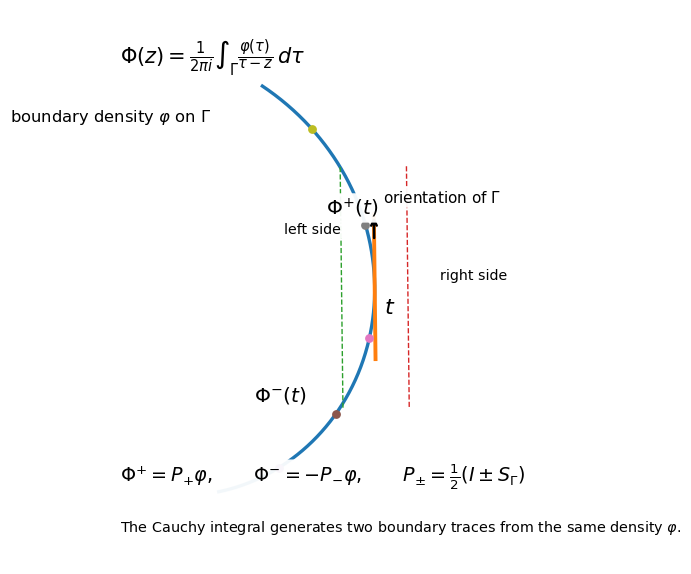

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

a = 0.36
b = 0.17
theta = np.linspace(-1.2, 1.15, 700)
r = a * np.exp(b * theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

theta0 = 0.18
r0 = a * np.exp(b * theta0)
t_point = np.array([r0 * np.cos(theta0), r0 * np.sin(theta0)])

tangent = np.array([
    r0 * (b * np.cos(theta0) - np.sin(theta0)),
    r0 * (b * np.sin(theta0) + np.cos(theta0)),
])
tangent = tangent / np.linalg.norm(tangent)

left_normal = np.array([-tangent[1], tangent[0]])
right_normal = -left_normal

seg_s = np.linspace(-0.12, 0.12, 45)
seg = t_point[None, :] + seg_s[:, None] * tangent[None, :]

tube_s = np.linspace(-0.20, 0.20, 55)
tube = t_point[None, :] + tube_s[:, None] * tangent[None, :]
tube_left = tube + 0.055 * left_normal[None, :]
tube_right = tube + 0.055 * right_normal[None, :]

theta_samples = np.array([-0.85, -0.45, -0.05, 0.45, 0.90])
tau_points = []
for th in theta_samples:
    rr = a * np.exp(b * th)
    tau_points.append(np.array([rr * np.cos(th), rr * np.sin(th)]))
tau_points = np.array(tau_points)

s_path = np.linspace(0, 1, 42)

def curved_approach(side="left"):
    normal = left_normal if side == "left" else right_normal
    return (
        t_point[None, :]
        + (0.24 * (1 - s_path) ** 1.2)[:, None] * normal[None, :]
        + (0.07 * (1 - s_path) * (s_path - 0.18))[:, None] * tangent[None, :]
    )

path_plus = curved_approach("left")
path_minus = curved_approach("right")

n1, hold1 = len(path_plus), 8
n2, hold2 = len(path_minus), 8
hold3 = 18
nframes = n1 + hold1 + n2 + hold2 + hold3

fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.set_aspect("equal")
ax.axis("off")
pad = 0.46
ax.set_xlim(t_point[0] - pad, t_point[0] + pad)
ax.set_ylim(t_point[1] - pad, t_point[1] + pad)

label_box = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.95)

ax.plot(x, y, lw=2.4)
ax.plot(seg[:, 0], seg[:, 1], lw=2.8)
ax.annotate(
    "",
    xy=(seg[-1, 0], seg[-1, 1]),
    xytext=(seg[-9, 0], seg[-9, 1]),
    arrowprops=dict(arrowstyle="->", lw=1.8),
)
ax.text(seg[-1, 0] + 0.015, seg[-1, 1] + 0.02, "orientation of $\\Gamma$", fontsize=11, bbox=label_box)
ax.text(t_point[0] + 0.015, t_point[1] - 0.045, r"$t$", fontsize=16, bbox=label_box)

ax.plot(tube_left[:, 0], tube_left[:, 1], ls="--", lw=1.0)
ax.plot(tube_right[:, 0], tube_right[:, 1], ls="--", lw=1.0)
ax.text(
    t_point[0] + 0.17 * left_normal[0] + 0.07 * tangent[0] + 0.02,
    t_point[1] + 0.17 * left_normal[1] + 0.07 * tangent[1] + 0.02,
    "left side",
    fontsize=10.2,
    bbox=label_box,
)
ax.text(
    t_point[0] + 0.16 * right_normal[0] + 0.07 * tangent[0] - 0.05,
    t_point[1] + 0.16 * right_normal[1] + 0.07 * tangent[1] - 0.06,
    "right side",
    fontsize=10.2,
    bbox=label_box,
)

for p in tau_points:
    ax.plot([p[0]], [p[1]], marker="o", ms=5.3)

ax.text(-0.24, 0.34, r"boundary density $\varphi$ on $\Gamma$", fontsize=11.8, bbox=label_box)
ax.text(
    0.04, 0.95,
    r"$\Phi(z)=\frac{1}{2\pi i}\int_{\Gamma}\frac{\varphi(\tau)}{\tau-z}\,d\tau$",
    transform=ax.transAxes,
    fontsize=15,
    va="top",
    bbox=label_box,
)

plus_marker, = ax.plot([], [], marker="o", ms=7.0)
minus_marker, = ax.plot([], [], marker="o", ms=7.0)
plus_text = ax.text(0, 0, "", fontsize=14, bbox=label_box)
minus_text = ax.text(0, 0, "", fontsize=14, bbox=label_box)
plus_path_line, = ax.plot([], [], ls=":", lw=1.3)
minus_path_line, = ax.plot([], [], ls=":", lw=1.3)
plus_boundary_text = ax.text(0, 0, "", fontsize=14.5, bbox=label_box)
minus_boundary_text = ax.text(0, 0, "", fontsize=14.5, bbox=label_box)

final_formula = ax.text(
    0.04, 0.13, "",
    transform=ax.transAxes,
    fontsize=13.8,
    va="bottom",
    bbox=label_box,
)
bottom_note = ax.text(
    0.04, 0.05, "",
    transform=ax.transAxes,
    fontsize=10.4,
    va="bottom",
    bbox=label_box,
)

plus_arrow = None
minus_arrow = None

def clear_arrow(aobj):
    if aobj is not None:
        aobj.remove()
    return None

def update(frame):
    global plus_arrow, minus_arrow
    plus_arrow = clear_arrow(plus_arrow)
    minus_arrow = clear_arrow(minus_arrow)

    plus_marker.set_data([], [])
    minus_marker.set_data([], [])
    plus_text.set_text("")
    minus_text.set_text("")
    plus_path_line.set_data([], [])
    minus_path_line.set_data([], [])
    plus_boundary_text.set_text("")
    minus_boundary_text.set_text("")
    final_formula.set_text("")
    bottom_note.set_text("")

    if frame < n1:
        idx = frame
        pos = path_plus[idx]
        plus_marker.set_data([pos[0]], [pos[1]])
        plus_text.set_text(r"$z_{+}(s)$")
        plus_text.set_position((pos[0] + 0.02, pos[1] + 0.02))
        plus_path_line.set_data(path_plus[:idx + 1, 0], path_plus[:idx + 1, 1])
        plus_arrow = ax.annotate(
            "",
            xy=(t_point[0], t_point[1]),
            xytext=(pos[0], pos[1]),
            arrowprops=dict(arrowstyle="->", lw=1.5, ls="--"),
        )
        bottom_note.set_text(r"Approach from the left: $z_{+}(s)\to t$.")

    elif frame < n1 + hold1:
        plus_boundary_text.set_text(r"$\Phi^{+}(t)$")
        plus_boundary_text.set_position((t_point[0] - 0.08, t_point[1] + 0.12))
        bottom_note.set_text(r"Left boundary limit at the point $t$.")

    elif frame < n1 + hold1 + n2:
        idx = frame - (n1 + hold1)
        plus_boundary_text.set_text(r"$\Phi^{+}(t)$")
        plus_boundary_text.set_position((t_point[0] - 0.08, t_point[1] + 0.12))
        pos = path_minus[idx]
        minus_marker.set_data([pos[0]], [pos[1]])
        minus_text.set_text(r"$z_{-}(s)$")
        minus_text.set_position((pos[0] + 0.02, pos[1] - 0.09))
        minus_path_line.set_data(path_minus[:idx + 1, 0], path_minus[:idx + 1, 1])
        minus_arrow = ax.annotate(
            "",
            xy=(t_point[0], t_point[1]),
            xytext=(pos[0], pos[1]),
            arrowprops=dict(arrowstyle="->", lw=1.5, ls="--"),
        )
        bottom_note.set_text(r"Approach from the right: $z_{-}(s)\to t$.")

    elif frame < n1 + hold1 + n2 + hold2:
        plus_boundary_text.set_text(r"$\Phi^{+}(t)$")
        plus_boundary_text.set_position((t_point[0] - 0.08, t_point[1] + 0.12))
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.20, t_point[1] - 0.19))
        bottom_note.set_text(r"Two boundary traces attached to the same point $t\in\Gamma$.")

    else:
        plus_boundary_text.set_text(r"$\Phi^{+}(t)$")
        plus_boundary_text.set_position((t_point[0] - 0.08, t_point[1] + 0.12))
        minus_boundary_text.set_text(r"$\Phi^{-}(t)$")
        minus_boundary_text.set_position((t_point[0] - 0.20, t_point[1] - 0.19))
        final_formula.set_text(
            r"$\Phi^{+}=P_{+}\varphi,\qquad \Phi^{-}=-P_{-}\varphi,"
            r"\qquad P_{\pm}=\frac{1}{2}(I\pm S_{\Gamma})$"
        )
        bottom_note.set_text(r"The Cauchy integral generates two boundary traces from the same density $\varphi$.")

    return [
        plus_marker, minus_marker, plus_text, minus_text,
        plus_path_line, minus_path_line,
        plus_boundary_text, minus_boundary_text,
        final_formula, bottom_note
    ]

anim = FuncAnimation(fig, update, frames=nframes, interval=95, blit=False)
anim.save("haseman_fig6_boundary_traces.gif", writer=PillowWriter(fps=10), dpi=85)
plt.show()